## Pharmacy Simulation

Program: pharmacy.ipynb<br>

Description: Pharmacy model suggested by  S. M. Ross, "A Course in Simulation."  The following code simulates one day. 

In [29]:
import numpy as np

print('******************************************')
print('            Pharmacy Simulation')
print('******************************************\n')

minutes_in_day = 8*60  # number of minutes in 9:00-5:00 day

a = 32/minutes_in_day  # average number of arrivals per minute

# Notation:
#  at = arrival time of prescriptions
#  st = service time once they reach the front of queue
#  ft = finish time after waiting and being filled.
#

ncust = 1000 #200  # don't know how many customers, this is an upper bound (we hope)

# initialize arrays:
at = np.zeros(ncust)  

# Generate random arrival times (in minutes) assuming Poisson process:
r = np.random.rand(ncust)
iat = -1/a * np.log(r) # Generate inter-arrival times, exponential distribution
at[0] = iat[0]         # Arrival time of first customer

for i in range(1,ncust):
   at[i] = at[i-1] + iat[i]   # arrival times of other customers

# only the one arriving before 5:00 are accepted
ibefore5 = np.where(at<=minutes_in_day)   # index of arrival times before 5:00
at = at[ibefore5]                         # chop down the array to only these
ncust = len(at)                           # now we know how many customers

# Generate random service times for each customer:
# normal distribution with mean 10 minutes and standard deviation 4 minutes:
st = 10 + 4*np.random.randn(ncust)

# Compute time each customer finishes:
ft = np.zeros(ncust)
ft[0] = at[0]+st[0]  # finish time for first customer
for i in range(1,ncust):
   # compute finish time for each customer as the larger of
   # arrival time plus service time (if no wait)
   # finish time of previous customer plus service time (if wait)
   ft[i] = np.amax([at[i]+st[i],ft[i-1]+st[i]])

print('Finish time of last prescription:  %6.2f \n' % ft[ncust-1])

# Determine how many minutes late the pharmacist must stay past 5:00
minutes_late = np.amax([0, ft[ncust-1]-minutes_in_day])

print('Minutes past 5:00 that pharmacist must stay:    %6.2f \n' % minutes_late)

******************************************
            Pharmacy Simulation
******************************************

Finish time of last prescription:  480.38 

Minutes past 5:00 that pharmacist must stay:      0.38 



In [30]:
import numpy as np

print('******************************************')
print('            Pharmacy Simulation')
print('******************************************\n')

num_days = 10000  # Number of days to simulate
departure_times = np.zeros(num_days)
working_at_530 = np.zeros(num_days)
leave_at_5pm = np.zeros(num_days)

for day in range(num_days):
    minutes_in_day = 8*60  # number of minutes in 9:00-5:00 day

    a = 32/minutes_in_day  # average number of arrivals per minute

    # Notation:
    #  at = arrival time of prescriptions
    #  st = service time once they reach the front of queue
    #  ft = finish time after waiting and being filled.
    #

    ncust = 1000 #200  # don't know how many customers, this is an upper bound (we hope)

    # initialize arrays:
    at = np.zeros(ncust)  

    # Generate random arrival times (in minutes) assuming Poisson process:
    r = np.random.rand(ncust)
    iat = -1/a * np.log(r) # Generate inter-arrival times, exponential distribution
    at[0] = iat[0]         # Arrival time of first customer

    for i in range(1,ncust):
       at[i] = at[i-1] + iat[i]   # arrival times of other customers

    # only the one arriving before 5:00 are accepted
    ibefore5 = np.where(at<=minutes_in_day)   # index of arrival times before 5:00
    at = at[ibefore5]                         # chop down the array to only these
    ncust = len(at)                           # now we know how many customers

    # Generate random service times for each customer:
    # normal distribution with mean 10 minutes and standard deviation 4 minutes:
    st = 10 + 4*np.random.randn(ncust)

    # Compute time each customer finishes:
    ft = np.zeros(ncust)
    ft[0] = at[0]+st[0]  # finish time for first customer
    for i in range(1,ncust):
       # compute finish time for each customer as the larger of
       # arrival time plus service time (if no wait)
       # finish time of previous customer plus service time (if wait)
       ft[i] = np.amax([at[i]+st[i],ft[i-1]+st[i]])

    departure_times[day] = ft[ncust-1]
    if ft[ncust-1] > 510:  # 5:30 PM = 510 minutes after 9 AM
        working_at_530[day] = 1
    if ft[ncust-1] <= minutes_in_day:  # Can leave at or before 5:00 PM
        leave_at_5pm[day] = 1

# Average departure time
avg_departure = np.mean(departure_times)
avg_minutes_past_5pm = avg_departure - minutes_in_day
print('Average time pharmacist departs store at night')
print('  Average departure: %.2f minutes after 9 AM' % avg_departure)
print('  Average minutes past 5:00 PM: %.2f\n' % avg_minutes_past_5pm)

# Proportion still working at 5:30 PM
proportion_530 = np.mean(working_at_530)
print('Proportion of days still working at 5:30 PM')
print('  Proportion: %.4f (%.2f%%)' % (proportion_530, proportion_530*100))

# Proportion able to leave at 5:00 PM
proportion_leave_5pm = np.mean(leave_at_5pm)
print('\nProportion of days able to leave at 5:00 PM')
print('  Proportion: %.4f (%.2f%%)' % (proportion_leave_5pm, proportion_leave_5pm*100))
print('  Days leaving at/before 5:00: %d out of %d' % (int(np.sum(leave_at_5pm)), num_days))

******************************************
            Pharmacy Simulation
******************************************

Average time pharmacist departs store at night
  Average departure: 486.56 minutes after 9 AM
  Average minutes past 5:00 PM: 6.56

Proportion of days still working at 5:30 PM
  Proportion: 0.1101 (11.01%)

Proportion of days able to leave at 5:00 PM
  Proportion: 0.3288 (32.88%)
  Days leaving at/before 5:00: 3288 out of 10000


Number of days staying past 5:00 PM: 6712 out of 10000
That is 67.12% of days



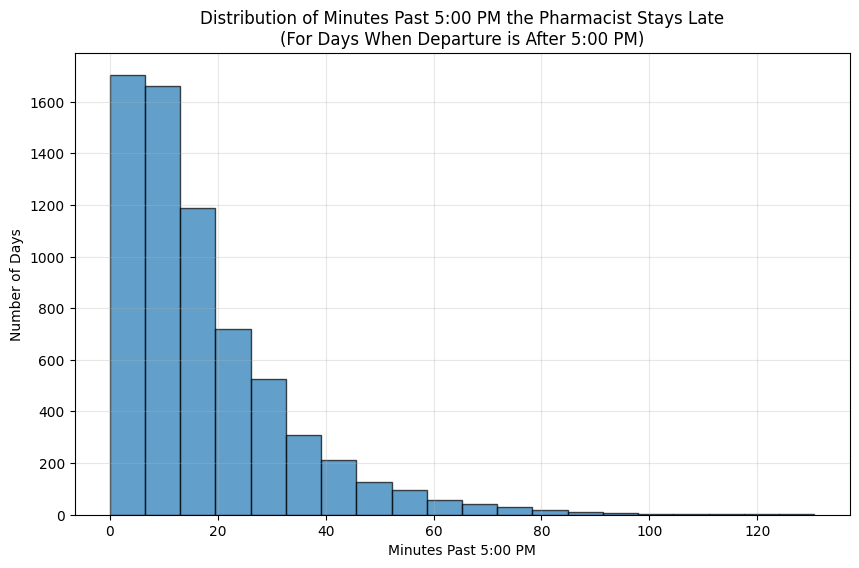

Statistics for late days:
  Mean: 17.35 minutes
  Median: 13.02 minutes
  Min: 0.01 minutes
  Max: 130.55 minutes
  Std Dev: 15.50 minutes


In [31]:
import matplotlib.pyplot as plt

# Filters for days where pharmacist stayed past 5:00 PM
minutes_in_day = 8*60  # 480 minutes
minutes_past_5pm = departure_times - minutes_in_day

# Only includes days where minutes_past_5pm > 0
late_days = minutes_past_5pm[minutes_past_5pm > 0]

print(f'Number of days staying past 5:00 PM: {len(late_days)} out of {num_days}')
print(f'That is {len(late_days)/num_days*100:.2f}% of days\n')

# Creates histogram with 20 bins min
plt.figure(figsize=(10, 6))
plt.hist(late_days, bins=20, edgecolor='black', alpha=0.7)
plt.xlabel('Minutes Past 5:00 PM')
plt.ylabel('Number of Days')
plt.title('Distribution of Minutes Past 5:00 PM the Pharmacist Stays Late\n(For Days When Departure is After 5:00 PM)')
plt.grid(True, alpha=0.3)
plt.show()

print(f'Statistics for late days:')
print(f'  Mean: {np.mean(late_days):.2f} minutes')
print(f'  Median: {np.median(late_days):.2f} minutes')
print(f'  Min: {np.min(late_days):.2f} minutes')
print(f'  Max: {np.max(late_days):.2f} minutes')
print(f'  Std Dev: {np.std(late_days):.2f} minutes')

***
## Here are some programming notes that may help. 

In [32]:
import numpy as np

### First let's make an array of 10 uniformly distributed random numbers.

In [33]:
randomNumbers = np.random.rand(10)
print(randomNumbers)

[0.33566465 0.21652099 0.59576701 0.83528876 0.18184079 0.76335892
 0.62330659 0.82130544 0.76462075 0.7003598 ]


### Let's find the indices of where the array elements are less than 0.5.  

In [34]:
indicesMeetingCondition = np.argwhere(randomNumbers < 0.5)
# We know have the indices that meet a condition. 
print(indicesMeetingCondition)

[[0]
 [1]
 [4]]


### Now, just find the length of that array.

In [35]:
len(indicesMeetingCondition)

3

### __BUT__, you might want to know how many elements there are __and__ create an array with those entries.  Here are commands for this: 

In [36]:
indicesMeetingConditionVersion2 = np.where(randomNumbers < 0.5)
# We know have the indices that meet a condition. 
print(indicesMeetingConditionVersion2)

(array([0, 1, 4]),)


### This time, we have a tuple with the first element being an array.  So, to the know the length we need to use: 

In [37]:
len(indicesMeetingConditionVersion2[0])

3

### Uh, why use this?  It's more complicated.  Here is why.  

In [38]:
newArray = randomNumbers[indicesMeetingConditionVersion2]
print(newArray)

[0.33566465 0.21652099 0.18184079]


### If you use indicesMeetingCondition rather than indicesMeetingConditionVersion2, then you get an array of arrays. 